<a href="https://colab.research.google.com/github/ART3MISH286/PRAHARI/blob/main/YOLO_PRAHARI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Sep 16 15:31:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q ultralytics

In [ ]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

print("YOLO successfully imported!")

YOLO successfully imported!


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1 = PRAHARI_ROOT / "datasets" / "dataset1"
DATASET2 = PRAHARI_ROOT / "datasets" / "dataset2"

MERGED = PRAHARI_ROOT / "merged"
RUNS = PRAHARI_ROOT / "runs"
MODELS = PRAHARI_ROOT / "models"

print("PRAHARI root :", PRAHARI_ROOT)
print("Dataset 1    :", DATASET1)
print("Dataset 2    :", DATASET2)
print("Merged       :", MERGED)
print("Runs         :", RUNS)
print("Models       :", MODELS)

PRAHARI root : /content/drive/MyDrive/PRAHARI
Dataset 1    : /content/drive/MyDrive/PRAHARI/datasets/dataset1
Dataset 2    : /content/drive/MyDrive/PRAHARI/datasets/dataset2
Merged       : /content/drive/MyDrive/PRAHARI/merged
Runs         : /content/drive/MyDrive/PRAHARI/runs
Models       : /content/drive/MyDrive/PRAHARI/models


In [ ]:
for name, path in {
    "DATASET 1": DATASET1,
    "DATASET 2": DATASET2
}.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Exists:", path.exists())

    if path.exists():
        print("Contents:")
        for item in sorted(path.iterdir()):
            print("  ", item.name)


DATASET 1
Exists: True
Contents:
   WEAPON_DETECTION_FINAL.v3i.yolov11

DATASET 2
Exists: True
Contents:
   Yolo Weapon Detection.v1i.yolov11


In [ ]:
import yaml
from pathlib import Path

# Actual YAML locations
DATASET1_YAML = DATASET1 / "WEAPON_DETECTION_FINAL.v3i.yolov11" / "data1.yaml"
DATASET2_YAML = DATASET2 / "Yolo Weapon Detection.v1i.yolov11" / "data2.yaml"

dataset_configs = {
    "DATASET 1": DATASET1_YAML,
    "DATASET 2": DATASET2_YAML
}

for name, yaml_path in dataset_configs.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("YAML:", yaml_path)
    print("Exists:", yaml_path.exists())

    if not yaml_path.exists():
        print("❌ YAML NOT FOUND")
        continue

    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    print("\nClasses:")

    names = config.get("names", {})

    if isinstance(names, list):
        for i, class_name in enumerate(names):
            print(f"  {i}: {class_name}")
    else:
        for class_id, class_name in names.items():
            print(f"  {class_id}: {class_name}")

    print("\nPaths from YAML:")
    print("  train:", config.get("train"))
    print("  val  :", config.get("val"))
    print("  test :", config.get("test"))


DATASET 1
YAML: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml
Exists: True

Classes:
  0: Grenade
  1: Gun
  2: Knife
  3: Pistol

Paths from YAML:
  train: ../train/images
  val  : ../valid/images
  test : ../test/images

DATASET 2
YAML: /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml
Exists: True

Classes:
  0: Gunmen
  1: Rifle
  2: blunt object
  3: knife
  4: knife_attacker
  5: person
  6: pistol
  7: shot-gun
  8: submachine-gun

Paths from YAML:
  train: ../train/images
  val  : ../valid/images
  test : ../test/images


In [ ]:
from pathlib import Path
import yaml

datasets = {
    "dataset1": DATASET1_YAML,
    "dataset2": DATASET2_YAML
}

resolved_paths = {}

for dataset_name, yaml_path in datasets.items():

    print("\n" + "=" * 70)
    print(f"{dataset_name.upper()} PATH VERIFICATION")
    print("=" * 70)

    # Load YAML
    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    # YAML is located inside the actual dataset folder
    dataset_root = yaml_path.parent

    print("Dataset root:", dataset_root)

    resolved_paths[dataset_name] = {}

    for split_name, yaml_key in [
        ("train", "train"),
        ("valid", "val"),
        ("test", "test")
    ]:

        relative_path = config.get(yaml_key)

        if relative_path is None:
            print(f"\n{split_name.upper()}: ❌ path missing from YAML")
            continue

        # Resolve path relative to YAML location
        image_dir = (dataset_root / relative_path).resolve()

        # Convert .../images → .../labels
        label_dir = image_dir.parent / "labels"

        resolved_paths[dataset_name][split_name] = {
            "images": image_dir,
            "labels": label_dir
        }

        image_count = len([
            p for p in image_dir.iterdir()
            if p.is_file()
        ]) if image_dir.exists() else 0

        label_count = len(
            list(label_dir.glob("*.txt"))
        ) if label_dir.exists() else 0

        print(f"\n{split_name.upper()}")
        print("  Images:", image_dir)
        print("  Exists:", image_dir.exists())
        print("  Count :", image_count)

        print("  Labels:", label_dir)
        print("  Exists:", label_dir.exists())
        print("  Count :", label_count)


DATASET1 PATH VERIFICATION
Dataset root: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11

TRAIN
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/train/images
  Exists: False
  Count : 0
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/train/labels
  Exists: False
  Count : 0

VALID
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/valid/images
  Exists: False
  Count : 0
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/valid/labels
  Exists: False
  Count : 0

TEST
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/test/images
  Exists: False
  Count : 0
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/test/labels
  Exists: False
  Count : 0

DATASET2 PATH VERIFICATION
Dataset root: /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11

TRAIN
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset2/train/images
  Exists: False
  Count : 0
  Labels: /content/drive

In [ ]:
import yaml

for name, yaml_path in {
    "DATASET 1": DATASET1_YAML,
    "DATASET 2": DATASET2_YAML
}.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    print("YAML location:")
    print(yaml_path)

    print("\nPath values stored inside YAML:")

    print("train =", repr(config.get("train")))
    print("val   =", repr(config.get("val")))
    print("test  =", repr(config.get("test")))


DATASET 1
YAML location:
/content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml

Path values stored inside YAML:
train = '../train/images'
val   = '../valid/images'
test  = '../test/images'

DATASET 2
YAML location:
/content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml

Path values stored inside YAML:
train = '../train/images'
val   = '../valid/images'
test  = '../test/images'


In [ ]:
from pathlib import Path

for path in [
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset1"),
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11"),
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset2"),
    Path("/content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11"),
]:

    print("\n", path)
    print("Exists:", path.exists())

    if path.exists():
        print("Contents:")
        for item in path.iterdir():
            print("  ", item.name)


 /content/drive/MyDrive/PRAHARI/datasets/dataset1
Exists: True
Contents:
   WEAPON_DETECTION_FINAL.v3i.yolov11

 /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
Exists: True
Contents:
   data1.yaml
   README.roboflow.txt
   README.dataset.txt
   valid
   train
   test

 /content/drive/MyDrive/PRAHARI/datasets/dataset2
Exists: True
Contents:
   Yolo Weapon Detection.v1i.yolov11

 /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
Exists: True
Contents:
   data2.yaml
   README.roboflow.txt
   README.dataset.txt
   train
   valid
   test


In [ ]:
from pathlib import Path

# Actual dataset roots based on the folder structure we just verified
DATASET1_ROOT = DATASET1_YAML.parent
DATASET2_ROOT = DATASET2_YAML.parent

dataset_roots = {
    "DATASET 1": DATASET1_ROOT,
    "DATASET 2": DATASET2_ROOT
}

resolved_paths = {}

for name, dataset_root in dataset_roots.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Dataset root:")
    print(dataset_root)

    resolved_paths[name] = {}

    for split in ["train", "valid", "test"]:

        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"

        image_count = len([
            p for p in image_dir.iterdir()
            if p.is_file()
        ]) if image_dir.exists() else 0

        label_count = len(
            list(label_dir.glob("*.txt"))
        ) if label_dir.exists() else 0

        resolved_paths[name][split] = {
            "images": image_dir,
            "labels": label_dir
        }

        print(f"\n{split.upper()}")
        print("  Images:", image_dir)
        print("  Exists:", image_dir.exists())
        print("  Count :", image_count)

        print("  Labels:", label_dir)
        print("  Exists:", label_dir.exists())
        print("  Count :", label_count)


DATASET 1
Dataset root:
/content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11

TRAIN
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/train/images
  Exists: True
  Count : 4195
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/train/labels
  Exists: True
  Count : 4195

VALID
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/valid/images
  Exists: True
  Count : 1361
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/valid/labels
  Exists: True
  Count : 1361

TEST
  Images: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/test/images
  Exists: True
  Count : 1264
  Labels: /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/test/labels
  Exists: True
  Count : 1264

DATASET 2
Dataset root:
/content/drive/MyDrive/PRA

In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 4: ORIGINAL DATASET CLASS DISTRIBUTION
# ============================================================

import yaml
from pathlib import Path
from collections import Counter

dataset_info = {
    "dataset1": {
        "root": DATASET1_ROOT,
        "yaml": DATASET1_YAML
    },
    "dataset2": {
        "root": DATASET2_ROOT,
        "yaml": DATASET2_YAML
    }
}

for dataset_name, info in dataset_info.items():

    print("\n" + "=" * 75)
    print(f"{dataset_name.upper()} CLASS DISTRIBUTION")
    print("=" * 75)

    # Load YAML
    with open(info["yaml"], "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    names = config["names"]

    # Convert names to a consistent dictionary
    if isinstance(names, list):
        class_names = {
            i: name for i, name in enumerate(names)
        }
    else:
        class_names = {
            int(k): v for k, v in names.items()
        }

    print("\nClasses:")
    for class_id, class_name in class_names.items():
        print(f"  {class_id}: {class_name}")

    print("\nAnnotation counts:")

    for split in ["train", "valid", "test"]:

        label_dir = info["root"] / split / "labels"

        counts = Counter()
        malformed = 0
        total_annotations = 0

        for label_file in label_dir.glob("*.txt"):

            with open(label_file, "r", encoding="utf-8") as f:

                for line in f:

                    parts = line.strip().split()

                    if not parts:
                        continue

                    # At this stage we only want to identify the class.
                    try:
                        class_id = int(float(parts[0]))
                        counts[class_id] += 1
                        total_annotations += 1

                    except (ValueError, IndexError):
                        malformed += 1

        print(f"\n  {split.upper()}")
        print(f"  Total annotations: {total_annotations}")

        for class_id in sorted(class_names):

            print(
                f"    {class_id:2d} | "
                f"{class_names[class_id]:20s} | "
                f"{counts[class_id]}"
            )

        if malformed:
            print(
                f"  ⚠️ Malformed annotation lines: {malformed}"
            )


DATASET1 CLASS DISTRIBUTION

Classes:
  0: Grenade
  1: Gun
  2: Knife
  3: Pistol

Annotation counts:

  TRAIN
  Total annotations: 7160
     0 | Grenade              | 1995
     1 | Gun                  | 2047
     2 | Knife                | 1507
     3 | Pistol               | 1611

  VALID
  Total annotations: 2361
     0 | Grenade              | 637
     1 | Gun                  | 649
     2 | Knife                | 545
     3 | Pistol               | 530

  TEST
  Total annotations: 2212
     0 | Grenade              | 650
     1 | Gun                  | 630
     2 | Knife                | 442
     3 | Pistol               | 490

DATASET2 CLASS DISTRIBUTION

Classes:
  0: Gunmen
  1: Rifle
  2: blunt object
  3: knife
  4: knife_attacker
  5: person
  6: pistol
  7: shot-gun
  8: submachine-gun

Annotation counts:

  TRAIN
  Total annotations: 6267
     0 | Gunmen               | 1369
     1 | Rifle                | 613
     2 | blunt object         | 1
     3 | knife           

In [ ]:
from pathlib import Path

# ============================================================
# PRAHARI DATASET PATHS
# ============================================================

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
)

DATASET1_YAML = DATASET1_ROOT / "data1.yaml"

DATASET2_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
)

DATASET2_YAML = DATASET2_ROOT / "data2.yaml"


print("Dataset 1 root :", DATASET1_ROOT)
print("Dataset 1 YAML :", DATASET1_YAML)
print("Dataset 2 root :", DATASET2_ROOT)
print("Dataset 2 YAML :", DATASET2_YAML)

print("\nExistence check:")
print("Dataset 1:", DATASET1_ROOT.exists())
print("Dataset 1 YAML:", DATASET1_YAML.exists())
print("Dataset 2:", DATASET2_ROOT.exists())
print("Dataset 2 YAML:", DATASET2_YAML.exists())

Dataset 1 root : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
Dataset 1 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml
Dataset 2 root : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
Dataset 2 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml

Existence check:
Dataset 1: True
Dataset 1 YAML: True
Dataset 2: True
Dataset 2 YAML: True


In [ ]:
from pathlib import Path

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
)

DATASET1_YAML = DATASET1_ROOT / "data1.yaml"

DATASET2_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
)

DATASET2_YAML = DATASET2_ROOT / "data2.yaml"

print("DATASET 1 ROOT :", DATASET1_ROOT)
print("DATASET 1 YAML :", DATASET1_YAML)
print()
print("DATASET 2 ROOT :", DATASET2_ROOT)
print("DATASET 2 YAML :", DATASET2_YAML)

print("\n" + "=" * 60)
print("DRIVE VERIFICATION")
print("=" * 60)

print("PRAHARI exists :", PRAHARI_ROOT.exists())
print("Dataset 1     :", DATASET1_ROOT.exists())
print("Dataset 1 YAML :", DATASET1_YAML.exists())
print("Dataset 2     :", DATASET2_ROOT.exists())
print("Dataset 2 YAML :", DATASET2_YAML.exists())

DATASET 1 ROOT : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11
DATASET 1 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset1/WEAPON_DETECTION_FINAL.v3i.yolov11/data1.yaml

DATASET 2 ROOT : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11
DATASET 2 YAML : /content/drive/MyDrive/PRAHARI/datasets/dataset2/Yolo Weapon Detection.v1i.yolov11/data2.yaml

DRIVE VERIFICATION
PRAHARI exists : True
Dataset 1     : True
Dataset 1 YAML : True
Dataset 2     : True
Dataset 2 YAML : True


In [ ]:
# ============================================================
# CELL 5: ORIGINAL DATASET CLASS DISTRIBUTION
# ============================================================

import yaml
from collections import Counter

dataset_info = {
    "dataset1": {
        "root": DATASET1_ROOT,
        "yaml": DATASET1_YAML
    },
    "dataset2": {
        "root": DATASET2_ROOT,
        "yaml": DATASET2_YAML
    }
}

for dataset_name, info in dataset_info.items():

    print("\n" + "=" * 75)
    print(f"{dataset_name.upper()} CLASS DISTRIBUTION")
    print("=" * 75)

    # Load YAML
    with open(info["yaml"], "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    names = config["names"]

    # Normalize class-name dictionary
    if isinstance(names, list):
        class_names = {
            i: name for i, name in enumerate(names)
        }
    else:
        class_names = {
            int(k): v for k, v in names.items()
        }

    print("\nClasses:")
    for class_id, class_name in class_names.items():
        print(f"  {class_id}: {class_name}")

    print("\nAnnotation counts:")

    for split in ["train", "valid", "test"]:

        label_dir = info["root"] / split / "labels"

        counts = Counter()
        malformed = 0
        total_annotations = 0

        for label_file in label_dir.glob("*.txt"):

            with open(label_file, "r", encoding="utf-8") as f:

                for line in f:

                    parts = line.strip().split()

                    if not parts:
                        continue

                    try:
                        class_id = int(float(parts[0]))

                        counts[class_id] += 1
                        total_annotations += 1

                    except (ValueError, IndexError):

                        malformed += 1

        print(f"\n  {split.upper()}")
        print(f"  Total annotations: {total_annotations}")

        for class_id in sorted(class_names):

            print(
                f"    {class_id:2d} | "
                f"{class_names[class_id]:20s} | "
                f"{counts[class_id]}"
            )

        if malformed:
            print(
                f"  ⚠️ Malformed annotation lines: "
                f"{malformed}"
            )


DATASET1 CLASS DISTRIBUTION

Classes:
  0: Grenade
  1: Gun
  2: Knife
  3: Pistol

Annotation counts:

  TRAIN
  Total annotations: 7160
     0 | Grenade              | 1995
     1 | Gun                  | 2047
     2 | Knife                | 1507
     3 | Pistol               | 1611

  VALID
  Total annotations: 2361
     0 | Grenade              | 637
     1 | Gun                  | 649
     2 | Knife                | 545
     3 | Pistol               | 530

  TEST
  Total annotations: 2212
     0 | Grenade              | 650
     1 | Gun                  | 630
     2 | Knife                | 442
     3 | Pistol               | 490

DATASET2 CLASS DISTRIBUTION

Classes:
  0: Gunmen
  1: Rifle
  2: blunt object
  3: knife
  4: knife_attacker
  5: person
  6: pistol
  7: shot-gun
  8: submachine-gun

Annotation counts:

  TRAIN
  Total annotations: 6267
     0 | Gunmen               | 1369
     1 | Rifle                | 613
     2 | blunt object         | 1
     3 | knife           

In [ ]:
# ============================================================
# CELL 6: PRAHARI 8-CLASS TAXONOMY
# ============================================================

PRAHARI_CLASSES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun",
}

# ------------------------------------------------------------
# DATASET 1
# ------------------------------------------------------------
# Original:
# 0 Grenade
# 1 Gun
# 2 Knife
# 3 Pistol

MAPPING_1 = {
    0: 5,       # Grenade -> grenade
    1: 1,       # Gun     -> gun
    2: 4,       # Knife   -> knife
    3: 2,       # Pistol  -> handgun
}

# ------------------------------------------------------------
# DATASET 2
# ------------------------------------------------------------
# Original:
# 0 Gunmen
# 1 Rifle
# 2 blunt object
# 3 knife
# 4 knife_attacker
# 5 person
# 6 pistol
# 7 shot-gun
# 8 submachine-gun

MAPPING_2 = {
    0: None,    # Gunmen         -> excluded
    1: 3,       # Rifle          -> rifle
    2: None,    # blunt object   -> excluded
    3: 4,       # knife          -> knife
    4: None,    # knife_attacker -> excluded
    5: 0,       # person         -> person
    6: 2,       # pistol         -> handgun
    7: 6,       # shot-gun       -> shotgun
    8: 7,       # submachine-gun -> submachine_gun
}

print("PRAHARI FINAL CLASS TAXONOMY")
print("=" * 50)

for class_id, class_name in PRAHARI_CLASSES.items():
    print(f"{class_id}: {class_name}")

print("\nDataset 1 mapping:")
for old, new in MAPPING_1.items():
    print(f"  {old} -> {new} ({PRAHARI_CLASSES[new]})")

print("\nDataset 2 mapping:")
for old, new in MAPPING_2.items():
    if new is None:
        print(f"  {old} -> EXCLUDED")
    else:
        print(f"  {old} -> {new} ({PRAHARI_CLASSES[new]})")

PRAHARI FINAL CLASS TAXONOMY
0: person
1: gun
2: handgun
3: rifle
4: knife
5: grenade
6: shotgun
7: submachine_gun

Dataset 1 mapping:
  0 -> 5 (grenade)
  1 -> 1 (gun)
  2 -> 4 (knife)
  3 -> 2 (handgun)

Dataset 2 mapping:
  0 -> EXCLUDED
  1 -> 3 (rifle)
  2 -> EXCLUDED
  3 -> 4 (knife)
  4 -> EXCLUDED
  5 -> 0 (person)
  6 -> 2 (handgun)
  7 -> 6 (shotgun)
  8 -> 7 (submachine_gun)


In [ ]:
# ============================================================
# CELL 7: PRAHARI 8-CLASS MERGER DRY RUN
# ============================================================

from collections import Counter

DATASET_CONFIGS = {
    "dataset1": {
        "root": DATASET1_ROOT,
        "mapping": MAPPING_1
    },
    "dataset2": {
        "root": DATASET2_ROOT,
        "mapping": MAPPING_2
    }
}

dry_run_stats = {
    dataset: {
        split: {
            "images": 0,
            "usable_images": 0,
            "empty_images": 0,
            "usable_annotations": 0,
            "excluded_annotations": 0
        }
        for split in ["train", "valid", "test"]
    }
    for dataset in DATASET_CONFIGS
}

merged_class_counts = Counter()

for dataset_name, config in DATASET_CONFIGS.items():

    root = config["root"]
    mapping = config["mapping"]

    print("\n" + "=" * 70)
    print(f"DRY RUN: {dataset_name.upper()}")
    print("=" * 70)

    for split in ["train", "valid", "test"]:

        image_dir = root / split / "images"
        label_dir = root / split / "labels"

        image_files = [
            p for p in image_dir.iterdir()
            if p.is_file()
        ]

        stats = dry_run_stats[dataset_name][split]
        stats["images"] = len(image_files)

        for image_path in image_files:

            label_path = label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                stats["empty_images"] += 1
                continue

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            usable_annotations = 0
            excluded_annotations = 0

            for line in lines:

                parts = line.strip().split()

                if not parts:
                    continue

                try:
                    old_class = int(float(parts[0]))
                except:
                    excluded_annotations += 1
                    continue

                if old_class not in mapping:
                    excluded_annotations += 1
                    continue

                new_class = mapping[old_class]

                if new_class is None:
                    excluded_annotations += 1
                    continue

                usable_annotations += 1
                merged_class_counts[new_class] += 1

            if usable_annotations > 0:

                stats["usable_images"] += 1
                stats["usable_annotations"] += usable_annotations
                stats["excluded_annotations"] += excluded_annotations

            else:

                stats["empty_images"] += 1


# ============================================================
# PRINT DATASET STATISTICS
# ============================================================

for dataset_name in DATASET_CONFIGS:

    print("\n" + "-" * 70)
    print(dataset_name.upper())

    for split in ["train", "valid", "test"]:

        s = dry_run_stats[dataset_name][split]

        print(f"\n{split.upper()}")
        print(f"  Original images       : {s['images']}")
        print(f"  Usable images         : {s['usable_images']}")
        print(f"  Empty/unusable images : {s['empty_images']}")
        print(f"  Usable annotations    : {s['usable_annotations']}")
        print(f"  Excluded annotations  : {s['excluded_annotations']}")


# ============================================================
# PROJECTED FINAL CLASS DISTRIBUTION
# ============================================================

print("\n\n" + "=" * 70)
print("PROJECTED PRAHARI CLASS DISTRIBUTION")
print("=" * 70)

for class_id, class_name in PRAHARI_CLASSES.items():

    print(
        f"{class_id}: "
        f"{class_name:18s} -> "
        f"{merged_class_counts[class_id]}"
    )


DRY RUN: DATASET1

DRY RUN: DATASET2

----------------------------------------------------------------------
DATASET1

TRAIN
  Original images       : 4195
  Usable images         : 3988
  Empty/unusable images : 207
  Usable annotations    : 7160
  Excluded annotations  : 0

VALID
  Original images       : 1361
  Usable images         : 1286
  Empty/unusable images : 75
  Usable annotations    : 2361
  Excluded annotations  : 0

TEST
  Original images       : 1264
  Usable images         : 1195
  Empty/unusable images : 69
  Usable annotations    : 2212
  Excluded annotations  : 0

----------------------------------------------------------------------
DATASET2

TRAIN
  Original images       : 3183
  Usable images         : 2875
  Empty/unusable images : 308
  Usable annotations    : 4237
  Excluded annotations  : 2023

VALID
  Original images       : 689
  Usable images         : 625
  Empty/unusable images : 64
  Usable annotations    : 939
  Excluded annotations  : 448

TEST
  Orig

In [ ]:
# ============================================================
# CELL 8: BUILD PRAHARI MERGED DATASET
# ============================================================

from pathlib import Path
import shutil
import yaml

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

MERGED_ROOT = PRAHARI_ROOT / "merged"

# Remove previous merged dataset if it exists
if MERGED_ROOT.exists():
    print(f"Removing previous merged dataset: {MERGED_ROOT}")
    shutil.rmtree(MERGED_ROOT)

# Create directory structure
for split in ["train", "valid", "test"]:
    (MERGED_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

print(f"Created fresh merged dataset at:")
print(MERGED_ROOT)


# ------------------------------------------------------------
# PRAHARI class names
# ------------------------------------------------------------

PRAHARI_NAMES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}


# ------------------------------------------------------------
# Merge datasets
# ------------------------------------------------------------

merge_stats = {
    dataset: {
        split: {
            "images": 0,
            "annotations": 0,
            "excluded_annotations": 0
        }
        for split in ["train", "valid", "test"]
    }
    for dataset in DATASET_CONFIGS
}


for dataset_name, config in DATASET_CONFIGS.items():

    root = config["root"]
    mapping = config["mapping"]

    print("\n" + "=" * 70)
    print(f"MERGING {dataset_name.upper()}")
    print("=" * 70)

    for split in ["train", "valid", "test"]:

        source_image_dir = root / split / "images"
        source_label_dir = root / split / "labels"

        output_image_dir = MERGED_ROOT / split / "images"
        output_label_dir = MERGED_ROOT / split / "labels"

        image_files = [
            p for p in source_image_dir.iterdir()
            if p.is_file()
        ]

        for image_path in image_files:

            label_path = source_label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                continue

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            new_label_lines = []
            excluded_count = 0

            for line in lines:

                parts = line.strip().split()

                if not parts:
                    continue

                # Need at least class + 4 coordinates
                if len(parts) < 5:
                    excluded_count += 1
                    continue

                try:
                    old_class = int(float(parts[0]))
                except:
                    excluded_count += 1
                    continue

                # Unsupported / excluded class
                if old_class not in mapping:
                    excluded_count += 1
                    continue

                new_class = mapping[old_class]

                if new_class is None:
                    excluded_count += 1
                    continue

                # Preserve all coordinate values for now.
                coordinates = parts[1:]

                new_line = (
                    str(new_class)
                    + " "
                    + " ".join(coordinates)
                )

                new_label_lines.append(new_line)

            # If nothing usable remains, don't copy the image
            if not new_label_lines:
                continue

            # Prefix avoids filename collisions
            new_stem = f"{dataset_name}_{image_path.stem}"

            destination_image = (
                output_image_dir /
                f"{new_stem}{image_path.suffix}"
            )

            destination_label = (
                output_label_dir /
                f"{new_stem}.txt"
            )

            shutil.copy2(
                image_path,
                destination_image
            )

            destination_label.write_text(
                "\n".join(new_label_lines) + "\n",
                encoding="utf-8"
            )

            merge_stats[dataset_name][split]["images"] += 1
            merge_stats[dataset_name][split]["annotations"] += len(
                new_label_lines
            )
            merge_stats[dataset_name][split]["excluded_annotations"] += (
                excluded_count
            )


# ------------------------------------------------------------
# Create data.yaml
# ------------------------------------------------------------

data_yaml = {
    "path": str(MERGED_ROOT),

    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",

    "nc": len(PRAHARI_NAMES),

    "names": PRAHARI_NAMES
}

DATA_YAML = MERGED_ROOT / "data.yaml"

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )


# ------------------------------------------------------------
# Print merge summary
# ------------------------------------------------------------

print("\n\n" + "=" * 70)
print("PRAHARI MERGE COMPLETE")
print("=" * 70)

for dataset_name in DATASET_CONFIGS:

    print(f"\n{dataset_name.upper()}")

    for split in ["train", "valid", "test"]:

        s = merge_stats[dataset_name][split]

        print(
            f"{split.upper():6s} | "
            f"images={s['images']:5d} | "
            f"annotations={s['annotations']:5d} | "
            f"excluded={s['excluded_annotations']:5d}"
        )

print("\n" + "=" * 70)
print("FINAL DATASET PATH")
print("=" * 70)

print(MERGED_ROOT)

print("\nDATA YAML:")
print(DATA_YAML)

print("\n" + "=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

for split in ["train", "valid", "test"]:

    image_count = len(
        list((MERGED_ROOT / split / "images").iterdir())
    )

    label_count = len(
        list((MERGED_ROOT / split / "labels").iterdir())
    )

    print(
        f"{split:6s} -> "
        f"images: {image_count:5d} | "
        f"labels: {label_count:5d}"
    )

Created fresh merged dataset at:
/content/drive/MyDrive/PRAHARI/merged

MERGING DATASET1

MERGING DATASET2


PRAHARI MERGE COMPLETE

DATASET1
TRAIN  | images= 3988 | annotations= 7160 | excluded=    0
VALID  | images= 1286 | annotations= 2361 | excluded=    0
TEST   | images= 1195 | annotations= 2212 | excluded=    0

DATASET2
TRAIN  | images= 2875 | annotations= 4237 | excluded= 2023
VALID  | images=  625 | annotations=  939 | excluded=  448
TEST   | images=  640 | annotations=  935 | excluded=  437

FINAL DATASET PATH
/content/drive/MyDrive/PRAHARI/merged

DATA YAML:
/content/drive/MyDrive/PRAHARI/merged/data.yaml

DATASET STRUCTURE
train  -> images:  6863 | labels:  6863
valid  -> images:  1911 | labels:  1911
test   -> images:  1835 | labels:  1835


In [ ]:
# ============================================================
# CELL 9: SAVE PRAHARI DATASET MERGER TO DRIVE
# ============================================================

from pathlib import Path

PROJECT_SCRIPTS = PRAHARI_ROOT / "scripts"
PROJECT_DOCS = PRAHARI_ROOT / "docs"

PROJECT_SCRIPTS.mkdir(parents=True, exist_ok=True)
PROJECT_DOCS.mkdir(parents=True, exist_ok=True)

MERGE_SCRIPT = PROJECT_SCRIPTS / "merge_prahari_dataset.py"

merge_script_content = r'''from pathlib import Path
from collections import Counter
import shutil
import yaml


# ============================================================
# PRAHARI DATASET MERGER
# ============================================================

PRAHARI_ROOT = Path("/content/drive/MyDrive/PRAHARI")

DATASET1_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset1"
    / "WEAPON_DETECTION_FINAL.v3i.yolov11"
)

DATASET2_ROOT = (
    PRAHARI_ROOT
    / "datasets"
    / "dataset2"
    / "Yolo Weapon Detection.v1i.yolov11"
)

MERGED_ROOT = PRAHARI_ROOT / "merged"


# ============================================================
# PRAHARI FINAL CLASS TAXONOMY
# ============================================================

PRAHARI_CLASSES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun",
}


# ============================================================
# DATASET CLASS MAPPINGS
# ============================================================

MAPPING_1 = {
    0: 5,       # Grenade -> grenade
    1: 1,       # Gun -> gun
    2: 4,       # Knife -> knife
    3: 2,       # Pistol -> handgun
}

MAPPING_2 = {
    0: None,    # Gunmen -> excluded
    1: 3,       # Rifle -> rifle
    2: None,    # blunt object -> excluded
    3: 4,       # knife -> knife
    4: None,    # knife_attacker -> excluded
    5: 0,       # person -> person
    6: 2,       # pistol -> handgun
    7: 6,       # shot-gun -> shotgun
    8: 7,       # submachine-gun -> submachine_gun
}


DATASET_CONFIGS = {
    "dataset1": {
        "root": DATASET1_ROOT,
        "mapping": MAPPING_1,
    },
    "dataset2": {
        "root": DATASET2_ROOT,
        "mapping": MAPPING_2,
    },
}


# ============================================================
# CREATE FRESH MERGED DATASET
# ============================================================

if MERGED_ROOT.exists():
    shutil.rmtree(MERGED_ROOT)

for split in ["train", "valid", "test"]:
    (MERGED_ROOT / split / "images").mkdir(
        parents=True,
        exist_ok=True
    )
    (MERGED_ROOT / split / "labels").mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# MERGE
# ============================================================

for dataset_name, config in DATASET_CONFIGS.items():

    root = config["root"]
    mapping = config["mapping"]

    for split in ["train", "valid", "test"]:

        source_image_dir = root / split / "images"
        source_label_dir = root / split / "labels"

        output_image_dir = MERGED_ROOT / split / "images"
        output_label_dir = MERGED_ROOT / split / "labels"

        image_files = [
            p for p in source_image_dir.iterdir()
            if p.is_file()
        ]

        for image_path in image_files:

            label_path = source_label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                continue

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            new_label_lines = []

            for line in lines:

                parts = line.strip().split()

                if len(parts) < 5:
                    continue

                try:
                    old_class = int(float(parts[0]))
                except ValueError:
                    continue

                if old_class not in mapping:
                    continue

                new_class = mapping[old_class]

                if new_class is None:
                    continue

                coordinates = parts[1:]

                new_label_lines.append(
                    str(new_class)
                    + " "
                    + " ".join(coordinates)
                )

            if not new_label_lines:
                continue

            new_stem = f"{dataset_name}_{image_path.stem}"

            destination_image = (
                output_image_dir
                / f"{new_stem}{image_path.suffix}"
            )

            destination_label = (
                output_label_dir
                / f"{new_stem}.txt"
            )

            shutil.copy2(
                image_path,
                destination_image
            )

            destination_label.write_text(
                "\n".join(new_label_lines) + "\n",
                encoding="utf-8"
            )


# ============================================================
# CREATE YOLO DATA CONFIGURATION
# ============================================================

data_yaml = {
    "path": str(MERGED_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(PRAHARI_CLASSES),
    "names": PRAHARI_CLASSES,
}

DATA_YAML = MERGED_ROOT / "data.yaml"

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )


print("PRAHARI dataset merge completed.")
print(f"Merged dataset: {MERGED_ROOT}")
print(f"Data YAML:      {DATA_YAML}")
'''


MERGE_SCRIPT.write_text(
    merge_script_content,
    encoding="utf-8"
)

print("Saved:")
print(MERGE_SCRIPT)

Saved:
/content/drive/MyDrive/PRAHARI/scripts/merge_prahari_dataset.py


In [ ]:
# ============================================================
# CELL 10: SAVE PRAHARI IMPLEMENTATION PROGRESS
# ============================================================

PROGRESS_FILE = PROJECT_DOCS / "implementation_progress.md"

progress = r'''# PRAHARI Implementation Progress

## Date

2026-09-21

## Current Phase

Visual threat detection dataset preparation.

---

## Project Scope

PRAHARI is being implemented as a security-focused AI system for visual threat detection and operator assistance.

Current prototype pipeline:

```text
Input Image / Video
        |
        v
YOLO Threat Detector
        |
        v
Confidence Filtering
        |
        v
Threat Assessment
        |
        v
Explainability
        |
        v
Voice Alert
        |
        v
Operator Dashboard

_IncompleteInputError: incomplete input (1227505213.py, line 7)

In [ ]:
# ============================================================
# CELL 10: SAVE PRAHARI IMPLEMENTATION PROGRESS
# ============================================================

from pathlib import Path

PROJECT_DOCS = PRAHARI_ROOT / "docs"
PROJECT_DOCS.mkdir(parents=True, exist_ok=True)

PROGRESS_FILE = PROJECT_DOCS / "implementation_progress.md"

progress_lines = [
    "# PRAHARI Implementation Progress",
    "",
    "## Date",
    "",
    "2026-09-21",
    "",
    "## Current Phase",
    "",
    "Visual threat detection dataset preparation.",
    "",
    "## Project Scope",
    "",
    "PRAHARI is being implemented as a security-focused AI system for visual threat detection and operator assistance.",
    "",
    "Current prototype pipeline:",
    "",
    "Input Image / Video",
    "        |",
    "        v",
    "YOLO Threat Detector",
    "        |",
    "        v",
    "Confidence Filtering",
    "        |",
    "        v",
    "Threat Assessment",
    "        |",
    "        v",
    "Explainability",
    "        |",
    "        v",
    "Voice Alert",
    "        |",
    "        v",
    "Operator Dashboard",
    "",
    "Future extensions include thermal, LiDAR, radar, RF, acoustic and multimodal sensing.",
    "",
    "## Dataset Preparation",
    "",
    "Two YOLO-format datasets are being merged.",
    "",
    "### Dataset 1",
    "",
    "WEAPON_DETECTION_FINAL.v3i.yolov11",
    "",
    "Original classes:",
    "",
    "0 = Grenade",
    "1 = Gun",
    "2 = Knife",
    "3 = Pistol",
    "",
    "Mapping:",
    "",
    "0 -> 5  grenade",
    "1 -> 1  gun",
    "2 -> 4  knife",
    "3 -> 2  handgun",
    "",
    "Original image counts:",
    "",
    "Train = 4195",
    "Valid = 1361",
    "Test  = 1264",
    "",
    "Usable image counts after class filtering:",
    "",
    "Train = 3988",
    "Valid = 1286",
    "Test  = 1195",
    "",
    "### Dataset 2",
    "",
    "Yolo Weapon Detection.v1i.yolov11",
    "",
    "Original classes:",
    "",
    "0 = Gunmen",
    "1 = Rifle",
    "2 = blunt object",
    "3 = knife",
    "4 = knife_attacker",
    "5 = person",
    "6 = pistol",
    "7 = shot-gun",
    "8 = submachine-gun",
    "",
    "Mapping:",
    "",
    "0 -> excluded",
    "1 -> 3  rifle",
    "2 -> excluded",
    "3 -> 4  knife",
    "4 -> excluded",
    "5 -> 0  person",
    "6 -> 2  handgun",
    "7 -> 6  shotgun",
    "8 -> 7  submachine_gun",
    "",
    "The excluded classes are removed at annotation level.",
    "",
    "If an image contains both supported and excluded annotations, the supported annotations are retained.",
    "",
    "If an image contains no supported annotations, the image is excluded from the merged dataset.",
    "",
    "## Final PRAHARI Taxonomy",
    "",
    "0 = person",
    "1 = gun",
    "2 = handgun",
    "3 = rifle",
    "4 = knife",
    "5 = grenade",
    "6 = shotgun",
    "7 = submachine_gun",
    "",
    "Total classes = 8",
    "",
    "## Merged Dataset",
    "",
    "Final merged dataset location:",
    "",
    "/content/drive/MyDrive/PRAHARI/merged",
    "",
    "Final image counts:",
    "",
    "Train = 6863",
    "Valid = 1911",
    "Test  = 1835",
    "Total = 10609 images",
    "",
    "Image-label correspondence:",
    "",
    "Train = 6863 images / 6863 labels",
    "Valid = 1911 images / 1911 labels",
    "Test  = 1835 images / 1835 labels",
    "",
    "## Projected Annotation Distribution",
    "",
    "person             = 2271",
    "gun                = 3326",
    "handgun            = 4114",
    "rifle              = 826",
    "knife              = 3488",
    "grenade            = 3282",
    "shotgun            = 491",
    "submachine_gun     = 46",
    "",
    "The submachine_gun class is retained but is highly underrepresented and will be evaluated separately.",
    "",
    "## Current Status",
    "",
    "Completed:",
    "",
    "- Google Drive dataset organization",
    "- Dataset 1 inspection",
    "- Dataset 2 inspection",
    "- Original class-distribution analysis",
    "- PRAHARI 8-class taxonomy definition",
    "- Dataset class mappings",
    "- Dry-run merger",
    "- Actual dataset merger",
    "- Merged dataset structure creation",
    "- YOLO data.yaml creation",
    "",
    "Not yet completed:",
    "",
    "- Merged annotation integrity validation",
    "- Polygon/segmentation annotation detection and repair if required",
    "- Ground-truth visualization",
    "- YOLO environment/GPU verification",
    "- YOLO11n baseline training",
    "- Validation and test evaluation",
    "- Confusion matrix",
    "- PR curves",
    "- Per-class metrics",
    "- Inference/FPS measurements",
    "- Explainability module",
    "- Voice alert module",
    "- Operator dashboard",
    "- Final GitHub documentation",
    "- Research-paper experiments",
    "",
    "## Reproducibility",
    "",
    "Large datasets, model weights and training runs should remain outside the Git repository.",
    "",
    "Google Drive stores:",
    "",
    "datasets/",
    "merged/",
    "runs/",
    "models/",
    "",
    "GitHub stores:",
    "",
    "scripts/",
    "configs/",
    "detection/",
    "explainability/",
    "voice_alert/",
    "dashboard/",
    "docs/",
    "README.md",
    "",
    "This keeps the repository lightweight and reproducible.",
]

PROGRESS_FILE.write_text(
    "\n".join(progress_lines),
    encoding="utf-8"
)

print("Progress document saved successfully.")
print(PROGRESS_FILE)
print()
print("File size:", PROGRESS_FILE.stat().st_size, "bytes")

Progress document saved successfully.
/content/drive/MyDrive/PRAHARI/docs/implementation_progress.md

File size: 3500 bytes


In [ ]:
# ============================================================
# CELL 11: VERIFY GITHUB-BOUND PROJECT FILES
# ============================================================

print("=" * 70)
print("PRAHARI GITHUB FILE VERIFICATION")
print("=" * 70)

files_to_verify = [
    MERGE_SCRIPT,
    PROGRESS_FILE,
]

all_exist = True

for file_path in files_to_verify:

    exists = file_path.exists()

    print(f"\n{file_path}")
    print(f"Exists: {exists}")

    if exists:
        print(f"Size  : {file_path.stat().st_size:,} bytes")
    else:
        all_exist = False

print("\n" + "=" * 70)

if all_exist:
    print("STATUS: READY TO COPY TO GITHUB REPOSITORY")
else:
    print("STATUS: ONE OR MORE FILES ARE MISSING")

PRAHARI GITHUB FILE VERIFICATION

/content/drive/MyDrive/PRAHARI/scripts/merge_prahari_dataset.py
Exists: True
Size  : 5,077 bytes

/content/drive/MyDrive/PRAHARI/docs/implementation_progress.md
Exists: True
Size  : 3,500 bytes

STATUS: READY TO COPY TO GITHUB REPOSITORY


In [ ]:
# ============================================================
# CELL 12: VERIFY PRAHARI DRIVE PROJECT FILES
# ============================================================

from pathlib import Path

print("=" * 70)
print("PRAHARI DRIVE STRUCTURE")
print("=" * 70)

for folder in [
    PRAHARI_ROOT,
    PRAHARI_ROOT / "scripts",
    PRAHARI_ROOT / "docs",
    PRAHARI_ROOT / "datasets",
    PRAHARI_ROOT / "merged",
]:
    print(f"{folder}")
    print(f"  Exists: {folder.exists()}")
    print()

print("=" * 70)
print("PROJECT FILES")
print("=" * 70)

for file_path in [
    PRAHARI_ROOT / "scripts" / "merge_prahari_dataset.py",
    PRAHARI_ROOT / "docs" / "implementation_progress.md",
    PRAHARI_ROOT / "merged" / "data.yaml",
]:
    print(f"\n{file_path}")
    print(f"  Exists: {file_path.exists()}")

    if file_path.exists():
        print(f"  Size  : {file_path.stat().st_size:,} bytes")

PRAHARI DRIVE STRUCTURE
/content/drive/MyDrive/PRAHARI
  Exists: True

/content/drive/MyDrive/PRAHARI/scripts
  Exists: True

/content/drive/MyDrive/PRAHARI/docs
  Exists: True

/content/drive/MyDrive/PRAHARI/datasets
  Exists: True

/content/drive/MyDrive/PRAHARI/merged
  Exists: True

PROJECT FILES

/content/drive/MyDrive/PRAHARI/scripts/merge_prahari_dataset.py
  Exists: True
  Size  : 5,077 bytes

/content/drive/MyDrive/PRAHARI/docs/implementation_progress.md
  Exists: True
  Size  : 3,500 bytes

/content/drive/MyDrive/PRAHARI/merged/data.yaml
  Exists: True
  Size  : 215 bytes


In [ ]:
# ============================================================
# CELL 13: VERIFY MERGED FOLDER FROM COLAB
# ============================================================

from pathlib import Path

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

print("=" * 70)
print("MERGED FOLDER CONTENTS")
print("=" * 70)

for item in sorted(MERGED_ROOT.iterdir()):
    if item.is_dir():
        print(f"[DIR ]  {item.name}/")
    else:
        print(f"[FILE]  {item.name}   ({item.stat().st_size:,} bytes)")

print("\n" + "=" * 70)
print("DATA.YAML CHECK")
print("=" * 70)

DATA_YAML = MERGED_ROOT / "data.yaml"

print("Path   :", DATA_YAML)
print("Exists :", DATA_YAML.exists())

if DATA_YAML.exists():
    print("Size   :", DATA_YAML.stat().st_size, "bytes")
    print("\nCONTENT:")
    print("-" * 50)
    print(DATA_YAML.read_text(encoding="utf-8"))

MERGED FOLDER CONTENTS
[FILE]  data.yaml   (215 bytes)
[DIR ]  test/
[DIR ]  train/
[DIR ]  valid/

DATA.YAML CHECK
Path   : /content/drive/MyDrive/PRAHARI/merged/data.yaml
Exists : True
Size   : 215 bytes

CONTENT:
--------------------------------------------------
path: /content/drive/MyDrive/PRAHARI/merged
train: train/images
val: valid/images
test: test/images
nc: 8
names:
  0: person
  1: gun
  2: handgun
  3: rifle
  4: knife
  5: grenade
  6: shotgun
  7: submachine_gun



In [ ]:
# ============================================================
# CELL 14: PRAHARI MERGED DATASET INTEGRITY VALIDATION
# ============================================================

from pathlib import Path
from collections import Counter

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

VALID_CLASS_IDS = set(range(8))

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

validation_results = {}

print("=" * 75)
print("PRAHARI MERGED DATASET INTEGRITY VALIDATION")
print("=" * 75)

for split in ["train", "valid", "test"]:

    image_dir = MERGED_ROOT / split / "images"
    label_dir = MERGED_ROOT / split / "labels"

    image_files = sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    label_files = sorted([
        p for p in label_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ])

    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}

    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)

    stats = {
        "images": len(image_files),
        "labels": len(label_files),
        "missing_labels": len(missing_labels),
        "orphan_labels": len(orphan_labels),
        "empty_labels": 0,
        "valid_annotations": 0,
        "invalid_annotations": 0,
        "polygon_annotations": 0,
        "invalid_class_ids": 0,
        "invalid_coordinates": 0,
        "non_numeric_values": 0,
    }

    class_counts = Counter()

    polygon_examples = []
    invalid_examples = []

    # --------------------------------------------------------
    # Validate every label file
    # --------------------------------------------------------

    for label_path in label_files:

        text = label_path.read_text(
            encoding="utf-8"
        )

        lines = [
            line.strip()
            for line in text.splitlines()
            if line.strip()
        ]

        if not lines:
            stats["empty_labels"] += 1
            continue

        for line_number, line in enumerate(lines, start=1):

            parts = line.split()

            # Standard YOLO detection:
            # class + x_center + y_center + width + height
            if len(parts) != 5:

                stats["invalid_annotations"] += 1

                # More than 5 values may indicate polygon
                # / segmentation-style annotation.
                if len(parts) > 5:

                    stats["polygon_annotations"] += 1

                    if len(polygon_examples) < 10:
                        polygon_examples.append(
                            (
                                str(label_path),
                                line_number,
                                len(parts),
                                line
                            )
                        )

                elif len(invalid_examples) < 10:

                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            # ------------------------------------------------
            # Class ID
            # ------------------------------------------------

            try:
                class_id = int(float(parts[0]))
            except ValueError:

                stats["invalid_annotations"] += 1
                stats["non_numeric_values"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            if class_id not in VALID_CLASS_IDS:

                stats["invalid_annotations"] += 1
                stats["invalid_class_ids"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            # ------------------------------------------------
            # Coordinates
            # ------------------------------------------------

            try:
                coordinates = [
                    float(value)
                    for value in parts[1:]
                ]
            except ValueError:

                stats["invalid_annotations"] += 1
                stats["non_numeric_values"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            # YOLO normalized coordinates must be [0, 1]
            if any(
                value < 0.0 or value > 1.0
                for value in coordinates
            ):

                stats["invalid_annotations"] += 1
                stats["invalid_coordinates"] += 1

                if len(invalid_examples) < 10:
                    invalid_examples.append(
                        (
                            str(label_path),
                            line_number,
                            line
                        )
                    )

                continue

            stats["valid_annotations"] += 1
            class_counts[class_id] += 1

    validation_results[split] = {
        "stats": stats,
        "class_counts": class_counts,
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
        "polygon_examples": polygon_examples,
        "invalid_examples": invalid_examples,
    }

    # --------------------------------------------------------
    # Print split results
    # --------------------------------------------------------

    print("\n" + "-" * 75)
    print(f"{split.upper()} DATASET")
    print("-" * 75)

    print(f"Images                    : {stats['images']}")
    print(f"Labels                    : {stats['labels']}")
    print(f"Missing labels            : {stats['missing_labels']}")
    print(f"Orphan labels             : {stats['orphan_labels']}")
    print(f"Empty label files         : {stats['empty_labels']}")
    print(f"Valid annotations         : {stats['valid_annotations']}")
    print(f"Invalid annotations       : {stats['invalid_annotations']}")
    print(f"Polygon-style annotations : {stats['polygon_annotations']}")
    print(f"Invalid class IDs         : {stats['invalid_class_ids']}")
    print(f"Invalid coordinates       : {stats['invalid_coordinates']}")
    print(f"Non-numeric values       : {stats['non_numeric_values']}")

    print("\nClass distribution:")

    for class_id in range(8):
        print(
            f"  {class_id}: "
            f"{PRAHARI_NAMES[class_id]:18s} -> "
            f"{class_counts[class_id]}"
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("FINAL VALIDATION SUMMARY")
print("=" * 75)

total_invalid = 0
total_polygons = 0
total_missing = 0
total_orphans = 0

for split in ["train", "valid", "test"]:

    stats = validation_results[split]["stats"]

    total_invalid += stats["invalid_annotations"]
    total_polygons += stats["polygon_annotations"]
    total_missing += stats["missing_labels"]
    total_orphans += stats["orphan_labels"]

print(f"Total invalid annotations : {total_invalid}")
print(f"Total polygon annotations : {total_polygons}")
print(f"Total missing labels      : {total_missing}")
print(f"Total orphan labels      : {total_orphans}")

print("\n" + "=" * 75)

if (
    total_invalid == 0
    and total_polygons == 0
    and total_missing == 0
    and total_orphans == 0
):
    print("STATUS: DATASET PASSED INTEGRITY VALIDATION")
else:
    print("STATUS: DATASET REQUIRES ANNOTATION CLEANUP")

print("=" * 75)


# ============================================================
# SHOW POLYGON EXAMPLES IF FOUND
# ============================================================

if total_polygons > 0:

    print("\nPOLYGON/SEGMENTATION EXAMPLES")
    print("=" * 75)

    for split in ["train", "valid", "test"]:

        examples = validation_results[split]["polygon_examples"]

        if examples:

            print(f"\n{split.upper()}:")

            for path, line_number, field_count, line in examples:
                print(f"\nFile       : {path}")
                print(f"Line       : {line_number}")
                print(f"Field count: {field_count}")
                print(f"Annotation : {line}")

PRAHARI MERGED DATASET INTEGRITY VALIDATION

---------------------------------------------------------------------------
TRAIN DATASET
---------------------------------------------------------------------------
Images                    : 6863
Labels                    : 6863
Missing labels            : 0
Orphan labels             : 0
Empty label files         : 0
Valid annotations         : 11363
Invalid annotations       : 34
Polygon-style annotations : 34
Invalid class IDs         : 0
Invalid coordinates       : 0
Non-numeric values       : 0

Class distribution:
  0: person             -> 1536
  1: gun                -> 2047
  2: handgun            -> 2651
  3: rifle              -> 585
  4: knife              -> 2181
  5: grenade            -> 1995
  6: shotgun            -> 338
  7: submachine_gun     -> 30

---------------------------------------------------------------------------
VALID DATASET
---------------------------------------------------------------------------
Images  

In [ ]:
# ============================================================
# CELL 8: REPAIR POLYGON ANNOTATIONS
# Convert YOLO segmentation polygons -> YOLO bounding boxes
# ============================================================

from pathlib import Path
import shutil

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

BACKUP_ROOT = MERGED_ROOT / "_polygon_label_backup"

splits = ["train", "valid", "test"]

converted_count = 0
bbox_count = 0
backup_count = 0

print("=" * 75)
print("PRAHARI POLYGON -> BOUNDING BOX CLEANUP")
print("=" * 75)

for split in splits:

    label_dir = MERGED_ROOT / split / "labels"
    backup_dir = BACKUP_ROOT / split

    backup_dir.mkdir(parents=True, exist_ok=True)

    split_converted = 0
    split_bbox = 0

    for label_path in label_dir.glob("*.txt"):

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        new_lines = []
        file_changed = False

        for line in lines:

            parts = line.strip().split()

            if not parts:
                continue

            # ------------------------------------------------
            # Standard YOLO bounding box
            # class + 4 coordinates = 5 fields
            # ------------------------------------------------
            if len(parts) == 5:
                new_lines.append(line)
                bbox_count += 1
                split_bbox += 1
                continue

            # ------------------------------------------------
            # Polygon annotation
            # class + x1 y1 x2 y2 ... xn yn
            # ------------------------------------------------
            if len(parts) > 5 and (len(parts) - 1) % 2 == 0:

                try:
                    class_id = int(float(parts[0]))
                    coords = [float(x) for x in parts[1:]]

                    xs = coords[0::2]
                    ys = coords[1::2]

                    if len(xs) < 2 or len(ys) < 2:
                        print(
                            f"WARNING: Could not convert {label_path.name}"
                        )
                        new_lines.append(line)
                        continue

                    # Bounding box enclosing the polygon
                    x_min = min(xs)
                    x_max = max(xs)
                    y_min = min(ys)
                    y_max = max(ys)

                    # Clamp to valid normalized YOLO range
                    x_min = max(0.0, min(1.0, x_min))
                    x_max = max(0.0, min(1.0, x_max))
                    y_min = max(0.0, min(1.0, y_min))
                    y_max = max(0.0, min(1.0, y_max))

                    x_center = (x_min + x_max) / 2
                    y_center = (y_min + y_max) / 2

                    width = x_max - x_min
                    height = y_max - y_min

                    converted_line = (
                        f"{class_id} "
                        f"{x_center:.10f} "
                        f"{y_center:.10f} "
                        f"{width:.10f} "
                        f"{height:.10f}"
                    )

                    new_lines.append(converted_line)

                    converted_count += 1
                    split_converted += 1
                    file_changed = True

                except Exception as e:

                    print(
                        f"WARNING: Failed to convert "
                        f"{label_path.name}: {e}"
                    )

                    new_lines.append(line)

            else:
                # Preserve unexpected lines for validation
                new_lines.append(line)

        # ----------------------------------------------------
        # Backup original file before modifying it
        # ----------------------------------------------------
        if file_changed:

            backup_path = backup_dir / label_path.name

            if not backup_path.exists():
                shutil.copy2(label_path, backup_path)
                backup_count += 1

            label_path.write_text(
                "\n".join(new_lines) + "\n",
                encoding="utf-8"
            )

    print(f"\n{split.upper()}")
    print(f"  Polygon annotations converted : {split_converted}")
    print(f"  Normal bounding boxes kept    : {split_bbox}")

print("\n" + "=" * 75)
print("CLEANUP COMPLETE")
print("=" * 75)

print(f"Total polygon annotations converted : {converted_count}")
print(f"Total original label files backed up: {backup_count}")
print(f"Backup location                     : {BACKUP_ROOT}")

PRAHARI POLYGON -> BOUNDING BOX CLEANUP

TRAIN
  Polygon annotations converted : 31
  Normal bounding boxes kept    : 11366

VALID
  Polygon annotations converted : 2
  Normal bounding boxes kept    : 3298

TEST
  Polygon annotations converted : 14
  Normal bounding boxes kept    : 3133

CLEANUP COMPLETE
Total polygon annotations converted : 47
Total original label files backed up: 13
Backup location                     : /content/drive/MyDrive/PRAHARI/merged/_polygon_label_backup


In [ ]:
# ============================================================
# CELL 8: FINAL POST-CLEANUP VALIDATION
# ============================================================

from pathlib import Path
from collections import Counter

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

CLASS_NAMES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}

splits = ["train", "valid", "test"]

total_errors = 0
total_polygons = 0

print("=" * 75)
print("PRAHARI FINAL POST-CLEANUP VALIDATION")
print("=" * 75)

for split in splits:

    image_dir = MERGED_ROOT / split / "images"
    label_dir = MERGED_ROOT / split / "labels"

    image_files = {
        p.stem: p
        for p in image_dir.iterdir()
        if p.is_file()
    }

    label_files = {
        p.stem: p
        for p in label_dir.iterdir()
        if p.is_file() and p.suffix == ".txt"
    }

    missing_labels = set(image_files) - set(label_files)
    orphan_labels = set(label_files) - set(image_files)

    empty_labels = 0
    invalid_annotations = 0
    polygon_annotations = 0
    invalid_class_ids = 0
    invalid_coordinates = 0
    non_numeric = 0

    valid_annotations = 0
    class_counts = Counter()

    for label_path in label_files.values():

        lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        if not any(line.strip() for line in lines):
            empty_labels += 1
            continue

        for line_number, line in enumerate(lines, start=1):

            parts = line.strip().split()

            if not parts:
                continue

            # ------------------------------------------------
            # YOLO detection format must contain 5 values
            # class x_center y_center width height
            # ------------------------------------------------
            if len(parts) != 5:

                polygon_annotations += 1
                invalid_annotations += 1
                total_polygons += 1

                continue

            # ------------------------------------------------
            # Numeric validation
            # ------------------------------------------------
            try:
                class_id = int(float(parts[0]))
                coords = [float(x) for x in parts[1:]]
            except ValueError:

                non_numeric += 1
                invalid_annotations += 1
                continue

            # ------------------------------------------------
            # Class ID validation
            # ------------------------------------------------
            if class_id not in CLASS_NAMES:

                invalid_class_ids += 1
                invalid_annotations += 1
                continue

            # ------------------------------------------------
            # Coordinate validation
            # ------------------------------------------------
            if any(x < 0 or x > 1 for x in coords):

                invalid_coordinates += 1
                invalid_annotations += 1
                continue

            # ------------------------------------------------
            # Valid annotation
            # ------------------------------------------------
            valid_annotations += 1
            class_counts[class_id] += 1

    total_errors += (
        len(missing_labels)
        + len(orphan_labels)
        + empty_labels
        + invalid_annotations
    )

    print("\n" + "-" * 75)
    print(f"{split.upper()} DATASET")
    print("-" * 75)

    print(f"Images                    : {len(image_files)}")
    print(f"Labels                    : {len(label_files)}")
    print(f"Missing labels            : {len(missing_labels)}")
    print(f"Orphan labels             : {len(orphan_labels)}")
    print(f"Empty label files         : {empty_labels}")
    print(f"Valid annotations         : {valid_annotations}")
    print(f"Invalid annotations       : {invalid_annotations}")
    print(f"Polygon-style annotations : {polygon_annotations}")
    print(f"Invalid class IDs         : {invalid_class_ids}")
    print(f"Invalid coordinates       : {invalid_coordinates}")
    print(f"Non-numeric values        : {non_numeric}")

    print("\nClass distribution:")

    for class_id, class_name in CLASS_NAMES.items():

        print(
            f"  {class_id}: "
            f"{class_name:18s} -> "
            f"{class_counts[class_id]}"
        )

print("\n" + "=" * 75)
print("FINAL STATUS")
print("=" * 75)

print(f"Total structural/annotation errors : {total_errors}")
print(f"Remaining polygon annotations      : {total_polygons}")

if total_errors == 0:

    print("\nSTATUS: DATASET IS CLEAN AND YOLO-READY")
    print("Next step: visual ground-truth verification")

else:

    print("\nSTATUS: DATASET STILL REQUIRES CLEANUP")
    print("DO NOT START TRAINING YET.")

PRAHARI FINAL POST-CLEANUP VALIDATION

---------------------------------------------------------------------------
TRAIN DATASET
---------------------------------------------------------------------------
Images                    : 6863
Labels                    : 6863
Missing labels            : 0
Orphan labels             : 0
Empty label files         : 0
Valid annotations         : 11397
Invalid annotations       : 0
Polygon-style annotations : 0
Invalid class IDs         : 0
Invalid coordinates       : 0
Non-numeric values        : 0

Class distribution:
  0: person             -> 1536
  1: gun                -> 2047
  2: handgun            -> 2654
  3: rifle              -> 613
  4: knife              -> 2181
  5: grenade            -> 1995
  6: shotgun            -> 341
  7: submachine_gun     -> 30

---------------------------------------------------------------------------
VALID DATASET
---------------------------------------------------------------------------
Images         


TRAIN VISUAL VERIFICATION


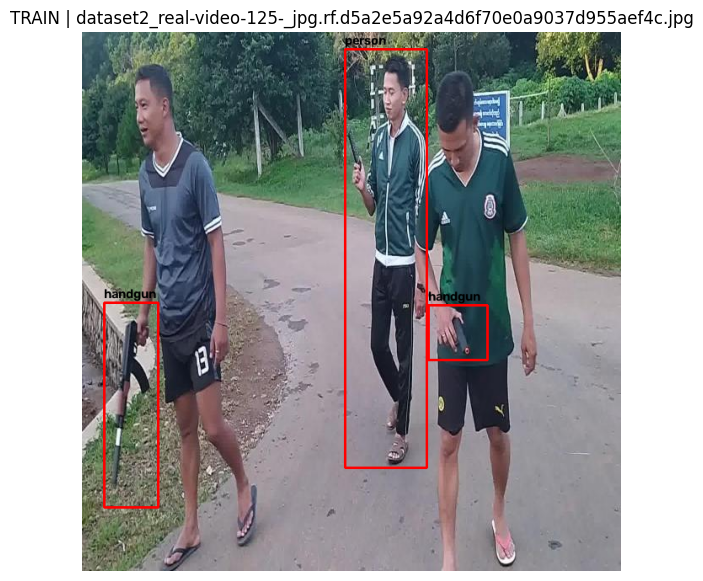

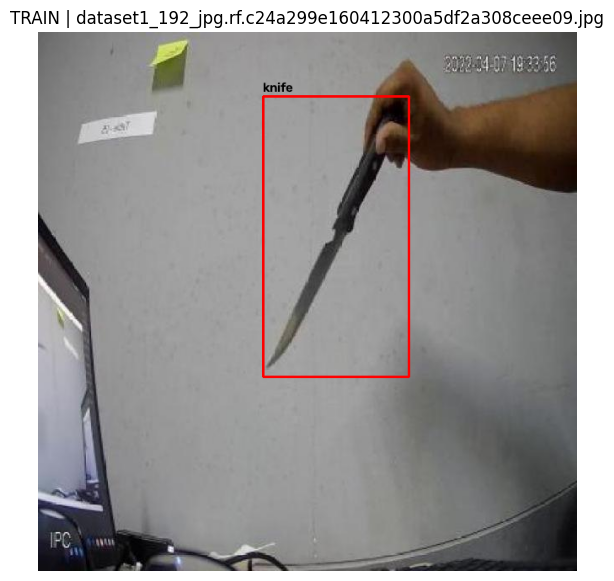

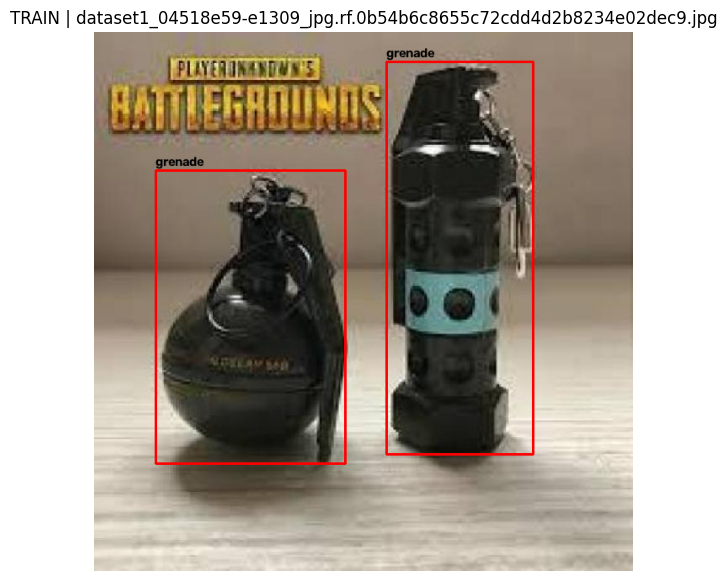


VALID VISUAL VERIFICATION


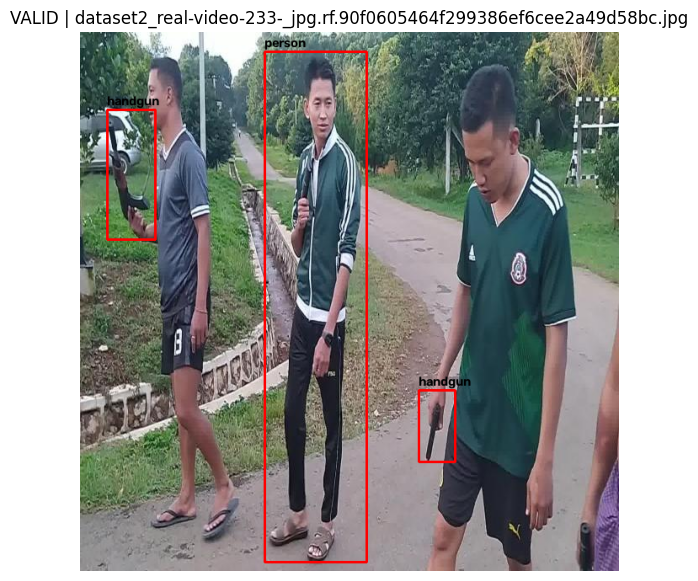

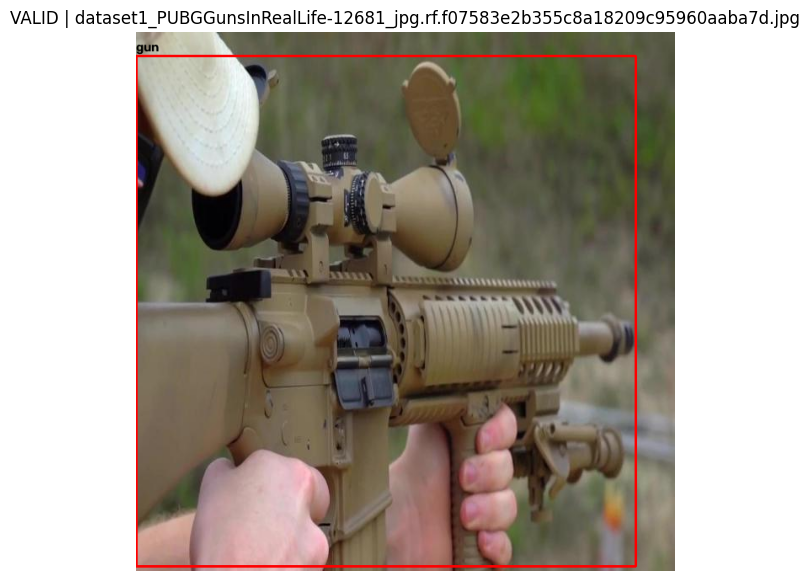

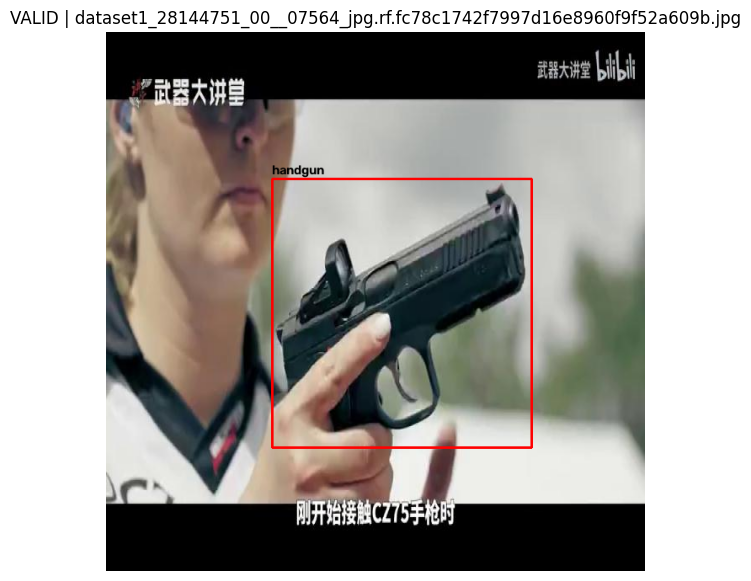


TEST VISUAL VERIFICATION


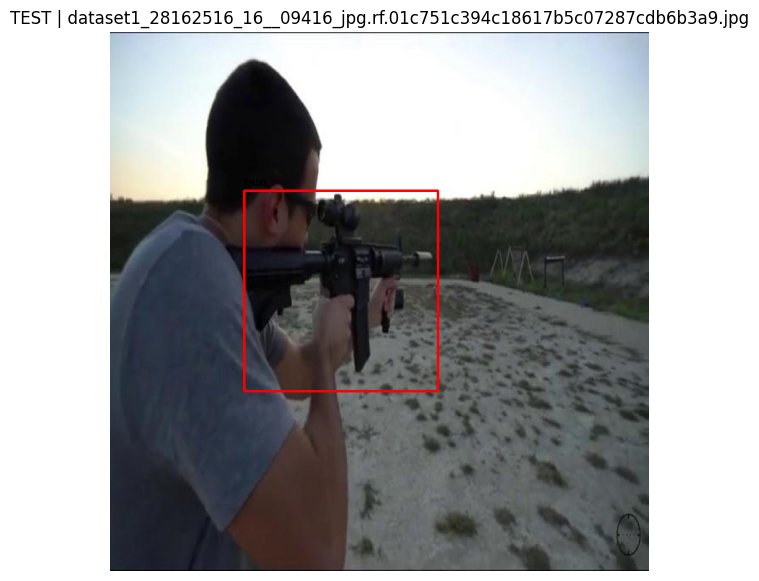

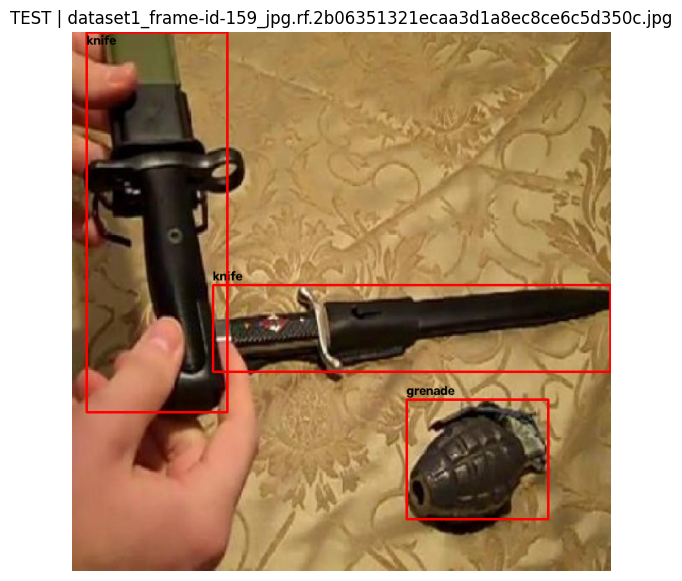

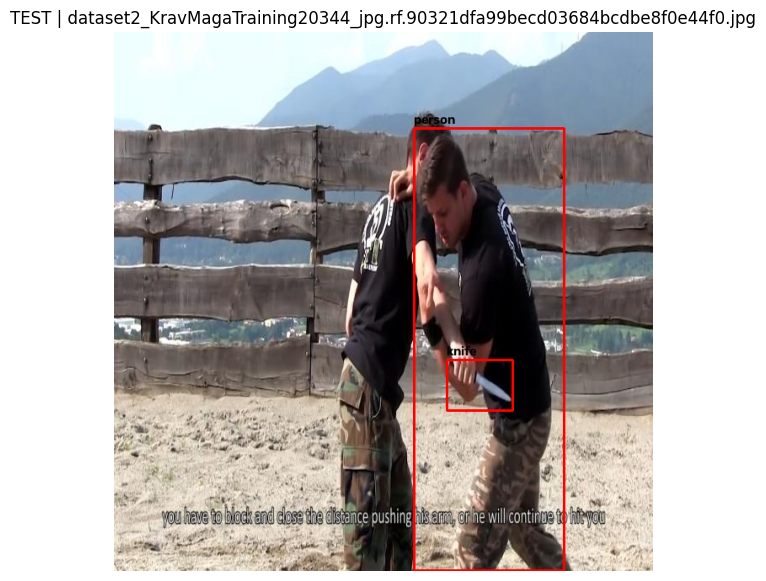

In [ ]:
# ============================================================
# CELL 9: PRAHARI VISUAL GROUND-TRUTH VERIFICATION
# ============================================================

import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

MERGED_ROOT = Path("/content/drive/MyDrive/PRAHARI/merged")

CLASS_NAMES = {
    0: "person",
    1: "gun",
    2: "handgun",
    3: "rifle",
    4: "knife",
    5: "grenade",
    6: "shotgun",
    7: "submachine_gun"
}

# Number of images to inspect from each split
SAMPLES_PER_SPLIT = 3

random.seed(42)

for split in ["train", "valid", "test"]:

    image_dir = MERGED_ROOT / split / "images"
    label_dir = MERGED_ROOT / split / "labels"

    image_files = [
        p for p in image_dir.iterdir()
        if p.is_file()
    ]

    selected_images = random.sample(
        image_files,
        min(SAMPLES_PER_SPLIT, len(image_files))
    )

    print("\n" + "=" * 70)
    print(f"{split.upper()} VISUAL VERIFICATION")
    print("=" * 70)

    for image_path in selected_images:

        label_path = label_dir / f"{image_path.stem}.txt"

        image = cv2.imread(str(image_path))

        if image is None:
            print(f"Could not read: {image_path.name}")
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        height, width = image.shape[:2]

        # ----------------------------------------------------
        # Read YOLO annotations
        # ----------------------------------------------------
        if label_path.exists():

            lines = label_path.read_text(
                encoding="utf-8"
            ).splitlines()

            for line in lines:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                class_id = int(float(parts[0]))

                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])

                # YOLO normalized -> pixel coordinates
                x1 = int(
                    (x_center - box_width / 2) * width
                )

                y1 = int(
                    (y_center - box_height / 2) * height
                )

                x2 = int(
                    (x_center + box_width / 2) * width
                )

                y2 = int(
                    (y_center + box_height / 2) * height
                )

                # Keep coordinates inside image
                x1 = max(0, min(width - 1, x1))
                y1 = max(0, min(height - 1, y1))
                x2 = max(0, min(width - 1, x2))
                y2 = max(0, min(height - 1, y2))

                class_name = CLASS_NAMES.get(
                    class_id,
                    f"class_{class_id}"
                )

                # Draw bounding box
                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

                # Draw label
                label = f"{class_name}"

                cv2.putText(
                    image,
                    label,
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 0, 0),
                    2
                )

        # ----------------------------------------------------
        # Display
        # ----------------------------------------------------
        plt.figure(figsize=(10, 7))
        plt.imshow(image)
        plt.title(
            f"{split.upper()} | {image_path.name}"
        )
        plt.axis("off")
        plt.show()

In [ ]:
# ============================================================
# CELL 10: PRAHARI YOLO ENVIRONMENT CHECK
# ============================================================

# ============================================================
# CELL 10A: INSTALL ULTRALYTICS
# ============================================================

!pip install -q -U ultralytics
import torch
import ultralytics

print("=" * 70)
print("PRAHARI YOLO ENVIRONMENT CHECK")
print("=" * 70)

print(f"\nUltralytics version : {ultralytics.__version__}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():

    print(f"GPU count           : {torch.cuda.device_count()}")
    print(f"GPU name            : {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory          : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

    print("\nSTATUS: GPU READY ✅")

else:

    print("\nSTATUS: GPU NOT AVAILABLE ❌")
    print("Go to Runtime -> Change runtime type -> T4 GPU")

print("\n" + "=" * 70)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 9.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
PRAHARI YOLO ENVIRONMENT CHECK

Ultralytics version : 8.4.157
PyTorch version     : 2.11.0+cu128
CUDA available      : True
GPU count           : 1
GPU name            : Tesla T4
GPU memory          : 14.56 GB

STATUS: GPU READY ✅



In [ ]:
# ============================================================
# CELL 11: VERIFY DATASET + LOAD YOLO11n
# ============================================================

from pathlib import Path
import yaml
from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_YAML = Path(
    "/content/drive/MyDrive/PRAHARI/merged/data.yaml"
)

# ------------------------------------------------------------
# Verify data.yaml exists
# ------------------------------------------------------------

print("=" * 70)
print("PRAHARI DATASET + YOLO11n CHECK")
print("=" * 70)

print(f"\nData YAML:")
print(DATA_YAML)

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Dataset YAML not found: {DATA_YAML}"
    )

print("YAML exists: ✅")

# ------------------------------------------------------------
# Read YAML
# ------------------------------------------------------------

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("\nDataset configuration:")
print("-" * 70)

print(f"Path   : {data.get('path')}")
print(f"Train  : {data.get('train')}")
print(f"Val    : {data.get('val')}")
print(f"Test   : {data.get('test')}")
print(f"Classes: {data.get('nc')}")

print("\nClass names:")
for class_id, class_name in data["names"].items():
    print(f"  {class_id}: {class_name}")

# ------------------------------------------------------------
# Verify expected 8-class taxonomy
# ------------------------------------------------------------

EXPECTED_CLASSES = [
    "person",
    "gun",
    "handgun",
    "rifle",
    "knife",
    "grenade",
    "shotgun",
    "submachine_gun"
]

actual_classes = list(data["names"].values())

if actual_classes != EXPECTED_CLASSES:
    raise ValueError(
        f"\nClass mismatch!\n"
        f"Expected: {EXPECTED_CLASSES}\n"
        f"Found:    {actual_classes}"
    )

if data["nc"] != 8:
    raise ValueError(
        f"Expected nc=8, found nc={data['nc']}"
    )

print("\nClass configuration: ✅ CORRECT")

# ------------------------------------------------------------
# Load YOLO11n
# ------------------------------------------------------------

print("\nLoading YOLO11n pretrained model...")

model = YOLO("yolo11n.pt")

print("\nYOLO11n loaded successfully! ✅")

print("=" * 70)
print("READY FOR BASELINE TRAINING")
print("=" * 70)

PRAHARI DATASET + YOLO11n CHECK

Data YAML:
/content/drive/MyDrive/PRAHARI/merged/data.yaml
YAML exists: ✅

Dataset configuration:
----------------------------------------------------------------------
Path   : /content/drive/MyDrive/PRAHARI/merged
Train  : train/images
Val    : valid/images
Test   : test/images
Classes: 8

Class names:
  0: person
  1: gun
  2: handgun
  3: rifle
  4: knife
  5: grenade
  6: shotgun
  7: submachine_gun

Class configuration: ✅ CORRECT

Loading YOLO11n pretrained model...

YOLO11n loaded successfully! ✅
READY FOR BASELINE TRAINING


In [ ]:
# ============================================================
# CELL 12: PRAHARI YOLO11n BASELINE TRAINING
# ============================================================

from ultralytics import YOLO

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_YAML = "/content/drive/MyDrive/PRAHARI/merged/data.yaml"

RUNS_DIR = "/content/drive/MyDrive/PRAHARI/runs"

# ------------------------------------------------------------
# Load pretrained YOLO11n
# ------------------------------------------------------------

model = YOLO("yolo11n.pt")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

results = model.train(
    data=DATA_YAML,

    epochs=50,
    imgsz=640,
    batch=16,

    device=0,
    workers=2,

    pretrained=True,

    patience=10,

    project=RUNS_DIR,
    name="yolo11n_baseline",

    save=True,
    plots=True,

    verbose=True
)

print("\n" + "=" * 70)
print("PRAHARI YOLO11n BASELINE TRAINING COMPLETE")
print("=" * 70)

print("\nResults saved to:")
print(f"{RUNS_DIR}/yolo11n_baseline")

print("\nBest model:")
print(f"{RUNS_DIR}/yolo11n_baseline/weights/best.pt")

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PRAHARI/merged/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_baseline-2, nbs=64, 

In [1]:
# ============================================================
# CELL 13: PRAHARI BASELINE METRICS
# ============================================================

from pathlib import Path
import pandas as pd

RUN_DIR = Path(
    "/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline"
)

RESULTS_CSV = RUN_DIR / "results.csv"
BEST_MODEL = RUN_DIR / "weights/best.pt"
LAST_MODEL = RUN_DIR / "weights/last.pt"

print("=" * 70)
print("PRAHARI YOLO11n BASELINE RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

print("\nRun directory:")
print(RUN_DIR)

print(f"\nresults.csv : {RESULTS_CSV.exists()}")
print(f"best.pt     : {BEST_MODEL.exists()}")
print(f"last.pt     : {LAST_MODEL.exists()}")

if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"results.csv not found at:\n{RESULTS_CSV}"
    )

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------

df = pd.read_csv(RESULTS_CSV)

# Remove accidental whitespace from column names
df.columns = df.columns.str.strip()

print("\nAvailable metric columns:")
for col in df.columns:
    print(f"  {col}")

# ------------------------------------------------------------
# Show final epoch
# ------------------------------------------------------------

final_epoch = df.iloc[-1]

print("\n" + "=" * 70)
print("FINAL EPOCH METRICS")
print("=" * 70)

for col in df.columns:
    if col != "epoch":
        value = final_epoch[col]

        if pd.notna(value):
            try:
                print(f"{col:<45} {float(value):.4f}")
            except:
                print(f"{col:<45} {value}")

# ------------------------------------------------------------
# Find best epoch using validation mAP50-95
# ------------------------------------------------------------

map95_candidates = [
    col for col in df.columns
    if "mAP50-95" in col
]

if map95_candidates:

    map95_col = map95_candidates[0]

    best_idx = df[map95_col].idxmax()
    best_row = df.loc[best_idx]

    print("\n" + "=" * 70)
    print("BEST EPOCH BY VALIDATION mAP50-95")
    print("=" * 70)

    print(f"\nEpoch: {int(best_row['epoch'])}")

    for col in df.columns:
        if col == "epoch":
            continue

        value = best_row[col]

        if pd.notna(value):
            try:
                print(f"{col:<45} {float(value):.4f}")
            except:
                print(f"{col:<45} {value}")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PRAHARI BASELINE METRICS EXTRACTED ✅")
print("=" * 70)

PRAHARI YOLO11n BASELINE RESULTS

Run directory:
/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline

results.csv : False
best.pt     : False
last.pt     : False


FileNotFoundError: results.csv not found at:
/content/drive/MyDrive/PRAHARI/runs/yolo11n_baseline/results.csv